In [ ]:
# 1. Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# 2. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 3. Paths
train_dir = "/content/drive/MyDrive/Stego-Project/train"
val_dir   = "/content/drive/MyDrive/Stego-Project/val"
test_dir  = "/content/drive/MyDrive/Stego-Project/test"

In [ ]:
import os

base_path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(base_path):
    if "train" in dirs and "val" in dirs and "test" in dirs:
        print("✅ Dataset Found at:", root)
        dataset_path = root
        break

✅ Dataset Found at: /content/drive/MyDrive/Stego-PVD-dataset/Stego-pvd-dataset


In [ ]:
train_dir = os.path.join(dataset_path, "train")
val_dir   = os.path.join(dataset_path, "val")
test_dir  = os.path.join(dataset_path, "test")

print("Train Path:", train_dir)
print("Val Path:", val_dir)
print("Test Path:", test_dir)

Train Path: /content/drive/MyDrive/Stego-PVD-dataset/Stego-pvd-dataset/train
Val Path: /content/drive/MyDrive/Stego-PVD-dataset/Stego-pvd-dataset/val
Test Path: /content/drive/MyDrive/Stego-PVD-dataset/Stego-pvd-dataset/test


In [ ]:
# 4. Image settings
img_size = (128, 128)
batch_size = 32

In [ ]:
# 5. Data augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
# 6. Load data
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 8005 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# 🔥 FULL TRAINING (IMPORTANT)
base_model.trainable = True

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Custom Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),  # 🔥 slow learning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    patience=3,
    factor=0.5,
    verbose=1
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 493ms/step - accuracy: 0.5028 - loss: 0.8858 - val_accuracy: 0.5077 - val_loss: 0.7669 - learning_rate: 5.0000e-06
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 122s 487ms/step - accuracy: 0.5021 - loss: 0.8700 - val_accuracy: 0.5033 - val_loss: 0.7951 - learning_rate: 5.0000e-06
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.4923 - loss: 0.8923
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 498ms/step - accuracy: 0.4926 - loss: 0.8919 - val_accuracy: 0.4955 - val_loss: 0.7959 - learning_rate: 5.0000e-06
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 495ms/step - accuracy: 0.5073 - loss: 0.8532 - val_accuracy: 0.4985 - val_loss: 0.7791 - learning_rate: 2.5000e-06
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 122s 485ms/step - accuracy: 0.4942 - loss: 0.8727 - val_accuracy: 0.4985 - val_loss: 0.7836 - learning_rate: 2.5000e-06


In [ ]:
 # Test
loss, acc = model.evaluate(test_data)
print("🔥 Final Accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1279s 10s/step - accuracy: 0.5027 - loss: 0.7877
🔥 Final Accuracy: 0.5027499794960022


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Predictions
pred = model.predict(test_data)
pred_labels = (pred > 0.5).astype(int).reshape(-1)

true_labels = test_data.classes

125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 201ms/step


In [ ]:
# CONFUSION MATRIX
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 938 1062]
 [ 927 1073]]


In [ ]:
# Classification Report (Precision, Recall, F1)
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels))


Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.47      0.49      2000
           1       0.50      0.54      0.52      2000

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



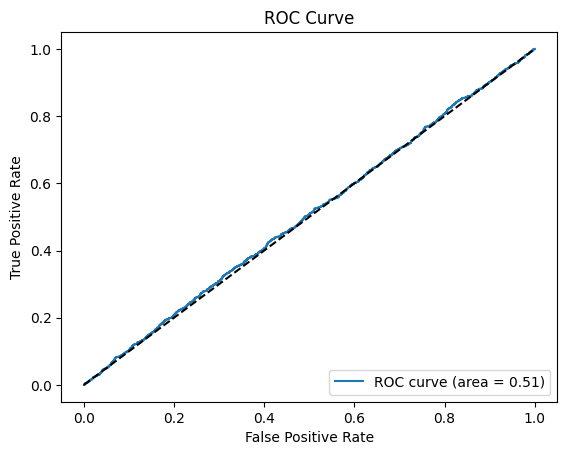

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(true_labels, pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Accuracy manually
accuracy = np.mean(pred_labels == true_labels)
print("\nAccuracy:", accuracy)


Accuracy: 0.50275


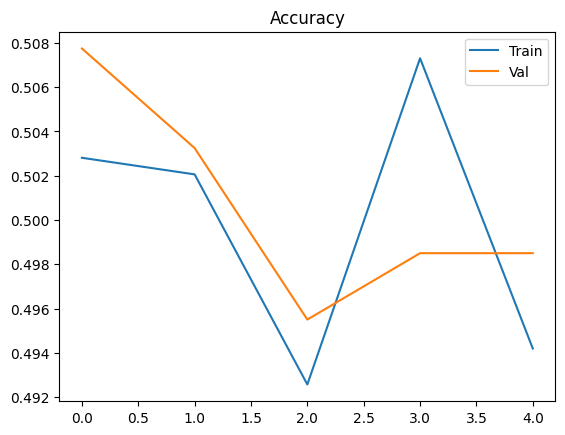

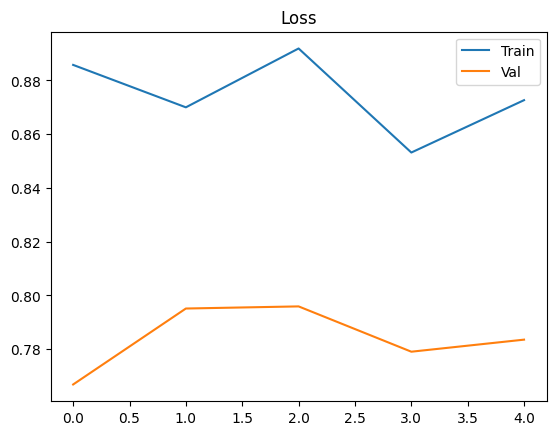

In [ ]:
# Graphs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Val"])
plt.show()

In [ ]:
model.save("stego_model.h5")

In [ ]:
print(train_data.classes)

[0 0 0 ... 1 1 1]


In [ ]:

unique, counts = np.unique(train_data.classes, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(4010), np.int32(1): np.int64(3995)}


In [ ]:
x_batch, y_batch = next(train_data)

print("Image shape:", x_batch.shape)
print("Label shape:", y_batch.shape)

Image shape: (32, 128, 128, 3)
Label shape: (32,)


In [ ]:
print(train_data.class_indices)

{'cleanTrain': 0, 'stegoTrain': 1}
